# Actor-Critic Reference Tracking for the Unbalanced Disk

This notebook trains and compares two actor-critic methods, A2C and PPO, for reference tracking of the unbalanced disk. The policy receives the disk state and the requested reference angle, and it has to swing up and settle close to a target within ±15° around the upright position.

The reward function, environment, and algorithm hyperparameters are defined in `a2c_reference_tracking_train.py`. The notebook uses these settings directly, trains fresh A2C and PPO policies, and then compares their learning behaviour, tracking accuracy, input use, and deterministic policy maps.


## 1. Setup

The observation is

$$x_k = [\sin(	heta_k), \cos(	heta_k), \omega_k, \sin(	heta_{ref}), \cos(	heta_{ref})].$$

The sine-cosine representation avoids a discontinuity at the angle wrapping point. The angular-velocity observation noise is kept as defined in the Python file, because this is useful for making the policy less sensitive to measurement noise in the real setup.


In [ ]:
import importlib
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from stable_baselines3.common.vec_env import DummyVecEnv

import a2c_reference_tracking_train as ref_rl
importlib.reload(ref_rl)

ALGORITHMS = ["A2C", "PPO"]
REFERENCE_DEGS = [-15.0, -10.0, -5.0, 0.0, 5.0, 10.0, 15.0]
TRAIN_EPISODES = 1500
EVAL_EPISODES = 20
DEVICE = "cpu"

print(f"Algorithms:      {ALGORITHMS}")
print(f"Reference range: ±{ref_rl.REF_RANGE_DEG}°")
print(f"Omega obs noise: {ref_rl.OBS_NOISE_OMEGA} rad/s")
print(f"Reward weights:  {ref_rl.REWARD_WEIGHTS}")
print(f"Reward params:   {ref_rl.REWARD_PARAMS}")
print(f"A2C hyperparams: {ref_rl.default_hyperparams('A2C')}")
print(f"PPO hyperparams: {ref_rl.default_hyperparams('PPO')}")
print(f"Episodes:        {TRAIN_EPISODES} x {ref_rl.EPISODE_STEPS} per algorithm")
print(f"Eval episodes:   {EVAL_EPISODES}")
print(f"Seed:            {ref_rl.SEED}")
print(f"Device:          {DEVICE}")


Algorithms:      ['A2C', 'PPO']
Reference range: ±15.0°
Omega obs noise: 0.3 rad/s
Reward weights:  {'swing_up': 0.5, 'capture': 12.0, 'top_speed_penalty': 1.0, 'omega_penalty': 0.02, 'action_penalty': 0.002, 'stall_penalty': 0.5}
Reward params:   {'balance_sigma_angle': 0.15, 'balance_sigma_omega': 1.5, 'top_gate_sigma': 0.25, 'top_speed_sigma': 8.0, 'omega_penalty_denom': 10.0, 'stall_omega_sigma': 0.75}
A2C hyperparams: {'seed': 7, 'episode_steps': 300, 'learning_rate': 0.0007, 'n_steps': 32, 'gamma': 0.99, 'gae_lambda': 0.95, 'vf_coef': 0.5, 'max_grad_norm': 0.5, 'net_arch_pi': [64, 64], 'net_arch_vf': [64, 64]}
PPO hyperparams: {'seed': 7, 'episode_steps': 300, 'learning_rate': 0.0002, 'n_steps': 1200, 'batch_size': 120, 'n_epochs': 8, 'gamma': 0.99, 'gae_lambda': 0.95, 'clip_range': 0.08, 'target_kl': 0.02, 'vf_coef': 0.5, 'max_grad_norm': 0.5, 'net_arch_pi': [128, 128], 'net_arch_vf': [128, 128]}
Episodes:        1500 x 300 per algorithm
Eval episodes:   20
Seed:            7
De

## 2. Environment check

Before training, the environment is reset once and one zero-voltage step is applied. This confirms that the observation has five entries and that the reference angle is included correctly.


In [ ]:
# Verify env produces correct observation shape before training
test_env = ref_rl.make_env(SEED)()
obs, info = test_env.reset(seed=SEED)
next_obs, reward, _, _, info = test_env.step(np.array([0.0], dtype=np.float32))
print(f'Obs shape:       {obs.shape}  (expected (5,): sin θ, cos θ, ω, sin θ_ref, cos θ_ref)')
print(f'theta_ref:       {np.degrees(info["theta_ref"]):.1f}°')
print(f'obs:             {obs}')
print(f'training reward: {reward:.4f}')
test_env.close()

Obs shape:       (5,)  (expected (5,): sin θ, cos θ, ω, sin θ_ref, cos θ_ref)
theta_ref:       167.3°
obs:             [-2.2743719e-04  1.0000000e+00 -4.2438600e-02  2.2002925e-01
 -9.7549325e-01]
training reward: -0.4999


## 3. Training A2C and PPO

Both algorithms are trained on the same reference-tracking environment and reward. A2C is the direct extension of the swing-up actor-critic controller. PPO is added because its clipped policy update usually gives more stable training on harder control tasks.

During training, a deterministic validation rollout is used to save the best checkpoint. This is important for on-policy reinforcement learning: the final policy after all updates is not always the best policy observed during training.


In [ ]:
import hashlib
import shutil
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback

class EpisodeReturnCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.timesteps = []
        self.returns = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.timesteps.append(self.num_timesteps)
                self.returns.append(float(info["episode"]["r"]))
        return True


def configure_algorithm(algorithm):
    algorithm = algorithm.upper()
    model_path, hyperparams = ref_rl.set_algorithm(algorithm)
    ref_rl.MODEL_PATH = model_path
    ref_rl.TRAIN_HYPERPARAMS = {
        **hyperparams,
        "seed": ref_rl.SEED,
        "episode_steps": ref_rl.EPISODE_STEPS,
    }
    return model_path, ref_rl.TRAIN_HYPERPARAMS.copy()


def train_reference_policy(algorithm):
    model_path, hyperparams = configure_algorithm(algorithm)
    entropy_coef = 0.0005 if algorithm.upper() == "PPO" else 0.005
    total_timesteps = TRAIN_EPISODES * ref_rl.EPISODE_STEPS

    best_model_dir = model_path.parent / f"{model_path.stem}_best"
    best_path = best_model_dir / "best_model"
    if best_model_dir.exists():
        shutil.rmtree(best_model_dir)

    train_env = DummyVecEnv([ref_rl.make_env(ref_rl.SEED, ref_rl.EPISODE_STEPS, ref_rl.OBS_NOISE_OMEGA)])
    eval_env = DummyVecEnv([ref_rl.make_env(ref_rl.SEED + 99, ref_rl.EPISODE_STEPS, 0.0)])
    model = ref_rl.build_model(train_env, DEVICE, entropy_coef)

    learning_callback = EpisodeReturnCallback()
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=str(best_model_dir),
        log_path=None,
        eval_freq=ref_rl.EPISODE_STEPS * 50,
        n_eval_episodes=EVAL_EPISODES,
        deterministic=True,
        verbose=0,
    )

    print(f"\n=== Training {algorithm.upper()} ===")
    print(f"model path:       {model_path}.zip")
    print(f"hyperparameters:  {hyperparams}")
    print(f"omega noise std:  {ref_rl.OBS_NOISE_OMEGA} rad/s")
    print(f"timesteps:        {total_timesteps:,}")

    t0 = time.perf_counter()
    model.learn(total_timesteps=total_timesteps, callback=[learning_callback, eval_callback], progress_bar=False)
    elapsed = time.perf_counter() - t0

    checkpoint_zip = best_path.with_suffix(".zip")
    if not checkpoint_zip.exists():
        raise FileNotFoundError(f"EvalCallback did not create {checkpoint_zip}")

    best_model = ref_rl.load_model(best_path, device=DEVICE)
    best_model.save(model_path)
    checkpoint_sha1 = hashlib.sha1(checkpoint_zip.read_bytes()).hexdigest()[:12]

    train_env.close()
    eval_env.close()

    config_path = ref_rl.save_config(
        model_path,
        entropy_coef=entropy_coef,
        total_timesteps=total_timesteps,
        training_time_s=elapsed,
        rollout_summary={
            "selection": "best deterministic validation checkpoint",
            "checkpoint_sha1": checkpoint_sha1,
        },
    )

    print(f"training time:    {elapsed:.1f}s ({total_timesteps / elapsed:.1f} steps/s)")
    print(f"saved best model: {model_path}.zip")
    print(f"saved config:     {config_path}")

    return {
        "algorithm": algorithm.upper(),
        "model": best_model,
        "model_path": model_path,
        "hyperparams": hyperparams,
        "entropy_coef": entropy_coef,
        "elapsed": elapsed,
        "timesteps": np.array(learning_callback.timesteps),
        "returns": np.array(learning_callback.returns),
    }


trained = {}
for algorithm in ALGORITHMS:
    trained[algorithm] = train_reference_policy(algorithm)

# Restore the default selected algorithm after training.
configure_algorithm(ALGORITHMS[0])



=== Training A2C ===
model path:       ref_models/a2c_ref_track_v1.zip
hyperparameters:  {'seed': 7, 'episode_steps': 300, 'learning_rate': 0.0007, 'n_steps': 32, 'gamma': 0.99, 'gae_lambda': 0.95, 'vf_coef': 0.5, 'max_grad_norm': 0.5, 'net_arch_pi': [64, 64], 'net_arch_vf': [64, 64]}
omega noise std:  0.3 rad/s
timesteps:        450,000
training time:    226.9s (1983.4 steps/s)
saved best model: ref_models/a2c_ref_track_v1.zip
saved config:     ref_models/a2c_ref_track_v1_config.json

=== Training PPO ===
model path:       ref_models/ppo_ref_track_noise_01.zip
hyperparameters:  {'seed': 7, 'episode_steps': 300, 'learning_rate': 0.0002, 'n_steps': 1200, 'batch_size': 120, 'n_epochs': 8, 'gamma': 0.99, 'gae_lambda': 0.95, 'clip_range': 0.08, 'target_kl': 0.02, 'vf_coef': 0.5, 'max_grad_norm': 0.5, 'net_arch_pi': [128, 128], 'net_arch_vf': [128, 128]}
omega noise std:  0.3 rad/s
timesteps:        450,000
training time:    224.1s (2008.4 steps/s)
saved best model: ref_models/ppo_ref_trac

(PosixPath('ref_models/a2c_ref_track_v1'),
 {'seed': 7,
  'episode_steps': 300,
  'learning_rate': 0.0007,
  'n_steps': 32,
  'gamma': 0.99,
  'gae_lambda': 0.95,
  'vf_coef': 0.5,
  'max_grad_norm': 0.5,
  'net_arch_pi': [64, 64],
  'net_arch_vf': [64, 64]})

## 4. Learning curves

The learning curves show the episode return during training. Individual episodes are noisy, so a moving average is plotted to show the trend. This plot is used to compare training stability, while the later reference-tracking table is used to judge final tracking accuracy.


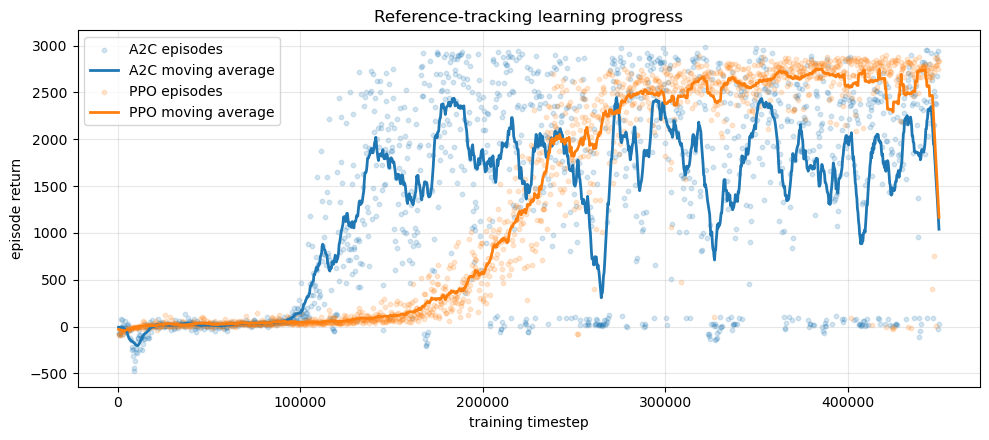

In [ ]:
def moving_average(values, window=25):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return values
    if len(values) < window:
        return np.full_like(values, values.mean())
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="same")

fig, ax = plt.subplots(figsize=(10, 4.5))
for algorithm, result in trained.items():
    ts = result["timesteps"]
    returns = result["returns"]
    ax.scatter(ts, returns, s=10, alpha=0.18, label=f"{algorithm} episodes")
    ax.plot(ts, moving_average(returns, window=25), lw=2.0, label=f"{algorithm} moving average")

ax.set_title("Reference-tracking learning progress")
ax.set_xlabel("training timestep")
ax.set_ylabel("episode return")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 5. Evaluation across the reference range

The trained policies are evaluated deterministically on references from −15° to +15°. The table reports both final tracking performance and rollout-level behaviour. The final error measures where the disk settles at the end of the episode, while the mean error also includes the swing-up transient.


In [ ]:
def evaluate_policy_on_references(model, algorithm, reference_degs):
    rows = []
    rollouts = {}
    for ref_deg in reference_degs:
        rewards, actions, infos = ref_rl.rollout(
            model,
            ref_rl.EPISODE_STEPS,
            theta_ref_deg=ref_deg,
            deterministic=True,
            obs_noise_omega=0.0,
        )
        theta_ref = infos[0]["theta_ref"]
        final_theta = infos[-1]["theta_wrapped"]
        ref_errors = np.array([info["ref_error"] for info in infos])
        final_signed_error_deg = np.degrees(ref_rl.wrap_angle(final_theta - theta_ref))
        final_offset_deg = np.degrees(ref_rl.wrap_angle(final_theta - np.pi))
        row = {
            "algorithm": algorithm,
            "ref_deg": float(ref_deg),
            "final_offset_deg": float(final_offset_deg),
            "final_signed_error_deg": float(final_signed_error_deg),
            "final_abs_error_deg": abs(float(final_signed_error_deg)),
            "mean_abs_error_deg": float(np.degrees(ref_errors.mean())),
            "return": float(rewards.sum()),
            "max_abs_u": float(np.abs(actions).max()),
        }
        rows.append(row)
        rollouts[(algorithm, ref_deg)] = {
            "rewards": rewards,
            "actions": actions,
            "infos": infos,
            **row,
        }
    return rows, rollouts

comparison_rows = []
comparison_rollouts = {}
for algorithm, result in trained.items():
    rows, rollouts = evaluate_policy_on_references(result["model"], algorithm, REFERENCE_DEGS)
    comparison_rows.extend(rows)
    comparison_rollouts.update(rollouts)

header = (
    "algorithm  ref [deg]  final offset [deg]  signed error [deg]  "
    "final |error| [deg]  mean |error| [deg]  return    max |u|"
)
print(header)
for row in comparison_rows:
    print(
        f"{row['algorithm']:>9}  {row['ref_deg']:>8.0f}"
        f"  {row['final_offset_deg']:>18.2f}"
        f"  {row['final_signed_error_deg']:>18.2f}"
        f"  {row['final_abs_error_deg']:>19.2f}"
        f"  {row['mean_abs_error_deg']:>18.2f}"
        f"  {row['return']:>7.1f}"
        f"  {row['max_abs_u']:>7.2f}"
    )


algorithm  ref [deg]  final offset [deg]  signed error [deg]  final |error| [deg]  mean |error| [deg]  return    max |u|
      A2C       -15               -7.32                7.68                 7.68               26.26   2087.3     3.00
      A2C       -10               -4.65                5.35                 5.35               23.92   2564.5     3.00
      A2C        -5               -1.84                3.16                 3.16               21.80   2913.3     3.00
      A2C         0                1.12                1.12                 1.12               19.79   3105.0     3.00
      A2C         5                4.20               -0.80                 0.80               19.01   3131.4     3.00
      A2C        10                7.38               -2.62                 2.62               20.26   3020.0     3.00
      A2C        15               10.67               -4.33                 4.33               21.65   2795.0     3.00
      PPO       -15              -17.70       

**Result summary.** The numerical table shows that PPO gives the better overall reference-tracking result in this run. Its mean final absolute error is $1.11^\circ$, compared with $3.58^\circ$ for A2C. PPO also has the smaller worst-case final error, $2.70^\circ$ at the $-15^\circ$ reference, while A2C reaches $7.68^\circ$ at the same reference. Both controllers use the full $\pm 3$ V input range, so the performance difference is mainly caused by the learned policy behaviour after swing-up rather than by different actuator limits.


## 6. Final achieved offset

The final achieved offset plot shows where each controller settles compared with the requested target. The dashed line is the ideal result. The labels show the signed final tracking error, so a positive value means that the final angle is above the target and a negative value means that it is below the target.


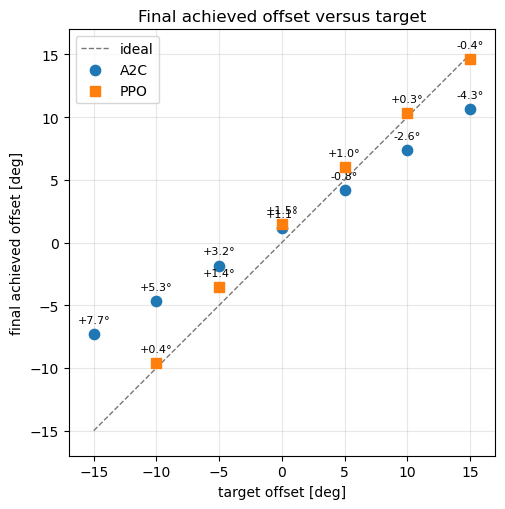

In [ ]:
colors = {"A2C": "tab:blue", "PPO": "tab:orange"}
markers = {"A2C": "o", "PPO": "s"}

fig, ax_offset = plt.subplots(figsize=(6.2, 5.2))

ax_offset.plot([-15, 15], [-15, 15], color="#777777", ls="--", lw=1, label="ideal")
for algorithm in ALGORITHMS:
    rows = [row for row in comparison_rows if row["algorithm"] == algorithm]
    refs = np.array([row["ref_deg"] for row in rows])
    offsets = np.array([row["final_offset_deg"] for row in rows])
    signed_errors = np.array([row["final_signed_error_deg"] for row in rows])
    ax_offset.scatter(refs, offsets, color=colors[algorithm], marker=markers[algorithm], s=55, label=algorithm, zorder=3)
    for ref_deg, offset_deg, signed_err in zip(refs, offsets, signed_errors):
        ax_offset.annotate(
            f"{signed_err:+.1f}°",
            (ref_deg, offset_deg),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=8,
        )

ax_offset.set_title("Final achieved offset versus target")
ax_offset.set_xlabel("target offset [deg]")
ax_offset.set_ylabel("final achieved offset [deg]")
ax_offset.set_xticks(REFERENCE_DEGS)
ax_offset.set_xlim(-17, 17)
ax_offset.set_ylim(-17, 17)
ax_offset.set_aspect("equal", adjustable="box")
ax_offset.grid(alpha=0.3)
ax_offset.legend()

fig.tight_layout()
plt.show()


**Observation.** The final-offset plot confirms that PPO follows the ideal diagonal more closely over most of the reference range. PPO tracks the positive references especially well, with final errors below about $1.5^\circ$ from $-10^\circ$ to $+15^\circ$. A2C also reaches the upright region and performs well near $0^\circ$ and $+5^\circ$, but it under-tracks the larger negative and positive offsets. This makes PPO the stronger final reference-tracking policy for the current training run.


## 7. Tracking trajectories and input voltage

The trajectory plots show the transient behaviour for −15°, 0°, and +15°. The right column shows the input voltage. This is useful because two controllers can have similar final errors while using different actuation patterns during swing-up and stabilization.


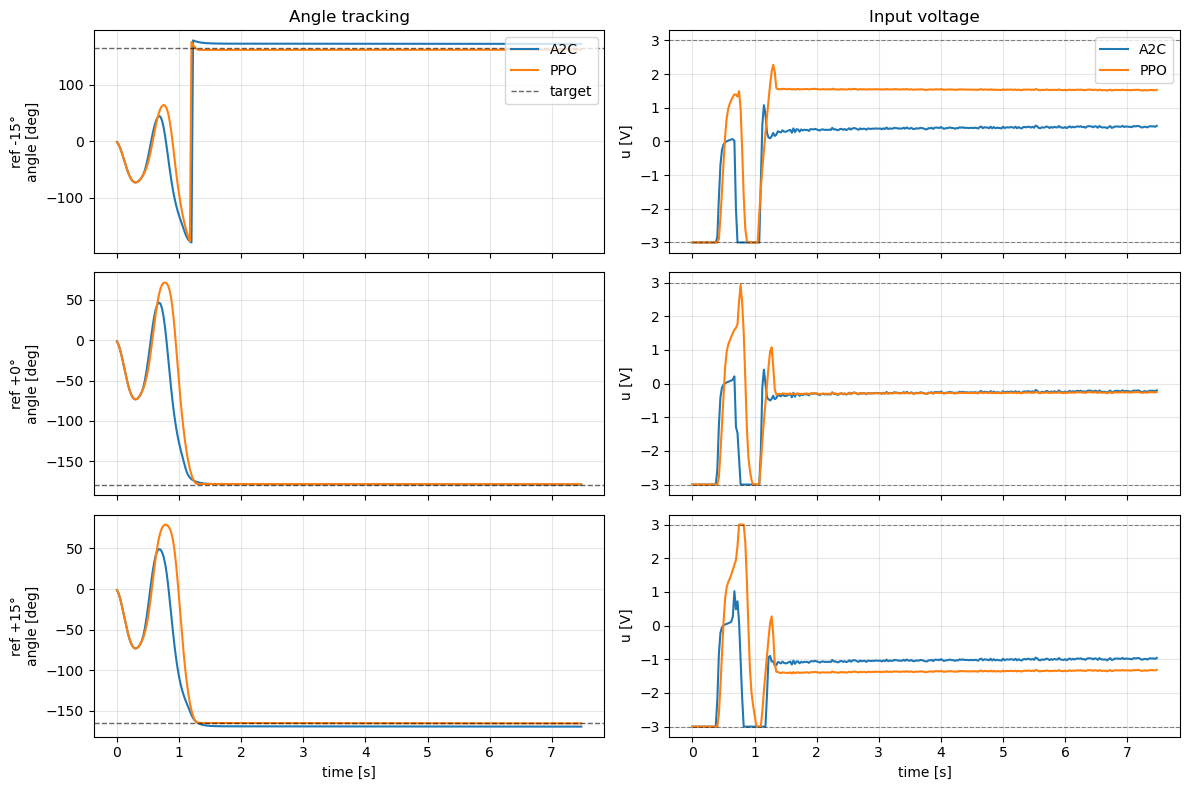

In [ ]:
selected_refs = [-15.0, 0.0, 15.0]
fig, axs = plt.subplots(len(selected_refs), 2, figsize=(12, 8), sharex=True)

for row_idx, ref_deg in enumerate(selected_refs):
    for algorithm in ALGORITHMS:
        rollout = comparison_rollouts[(algorithm, ref_deg)]
        infos = rollout["infos"]
        actions = rollout["actions"]
        t = np.arange(len(infos)) * 0.025
        angle_deg = np.degrees(np.array([info["theta_wrapped"] for info in infos]))
        theta_ref_deg = np.degrees(ref_rl.wrap_angle(infos[0]["theta_ref"]))

        axs[row_idx, 0].plot(t, angle_deg, color=colors[algorithm], label=algorithm)
        axs[row_idx, 1].plot(t, actions, color=colors[algorithm], label=algorithm)

    axs[row_idx, 0].axhline(theta_ref_deg, color="black", ls="--", lw=1, alpha=0.6, label="target" if row_idx == 0 else None)
    axs[row_idx, 1].axhline(3.0, color="black", ls="--", lw=0.8, alpha=0.45)
    axs[row_idx, 1].axhline(-3.0, color="black", ls="--", lw=0.8, alpha=0.45)
    axs[row_idx, 0].set_ylabel(f"ref {ref_deg:+.0f}°\nangle [deg]")
    axs[row_idx, 1].set_ylabel("u [V]")
    axs[row_idx, 1].set_ylim(-3.3, 3.3)
    axs[row_idx, 0].grid(alpha=0.3)
    axs[row_idx, 1].grid(alpha=0.3)

axs[0, 0].set_title("Angle tracking")
axs[0, 1].set_title("Input voltage")
axs[-1, 0].set_xlabel("time [s]")
axs[-1, 1].set_xlabel("time [s]")
axs[0, 0].legend(loc="upper right")
axs[0, 1].legend(loc="upper right")
fig.tight_layout()
plt.show()


**Observation.** The voltage plots show that both policies use saturation during the swing-up. This is expected for the unbalanced disk, because the controller must first inject enough energy to reach the upright region. After the transient, the input becomes smaller and is mainly used to correct the remaining offset. The final tracking difference therefore comes mostly from the stabilization behaviour near the reference, not from one method using a larger voltage range.


## 8. Policy maps for reference −15°

The policy maps show the deterministic voltage selected by each controller for a fixed reference of −15°. The yellow line shows the deterministic rollout for the same reference, so the map can be interpreted together with the part of the state space that the controller actually visits. The line is broken at angle wrapping jumps to avoid artificial horizontal connections across the plot.


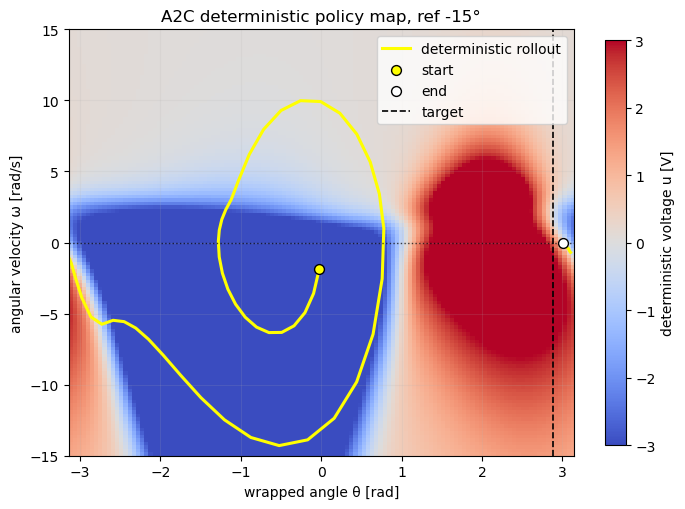

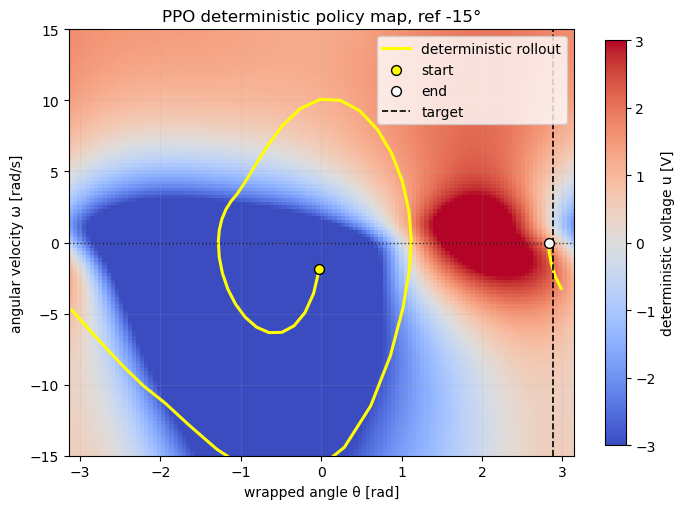

In [ ]:
POLICY_MAP_REF_DEG = -15.0
THETA_GRID = np.linspace(-np.pi, np.pi, 121)
OMEGA_GRID = np.linspace(-15.0, 15.0, 121)
THETA_MESH, OMEGA_MESH = np.meshgrid(THETA_GRID, OMEGA_GRID)


def reference_observation(theta_wrapped, omega, ref_deg):
    theta_ref = np.pi + np.deg2rad(ref_deg)
    return np.array([
        np.sin(theta_wrapped),
        np.cos(theta_wrapped),
        omega,
        np.sin(theta_ref),
        np.cos(theta_ref),
    ], dtype=np.float32)


def policy_voltage_map(model, ref_deg):
    voltages = np.zeros_like(THETA_MESH, dtype=float)
    for i in range(OMEGA_MESH.shape[0]):
        for j in range(OMEGA_MESH.shape[1]):
            obs = reference_observation(THETA_MESH[i, j], OMEGA_MESH[i, j], ref_deg)
            action, _ = model.predict(obs, deterministic=True)
            voltages[i, j] = float(np.asarray(action).reshape(-1)[0])
    return voltages


def rollout_state_trace(algorithm, ref_deg):
    rollout = comparison_rollouts[(algorithm, ref_deg)]
    infos = rollout["infos"]
    theta_trace = np.array([info["theta_wrapped"] for info in infos])
    omega_trace = np.array([info["omega"] for info in infos])

    # Break the plotted line when the wrapped angle jumps between +π and -π.
    # Otherwise matplotlib draws an artificial horizontal line across the map.
    jump_idx = np.where(np.abs(np.diff(theta_trace)) > np.pi)[0] + 1
    theta_plot = theta_trace.astype(float).copy()
    omega_plot = omega_trace.astype(float).copy()
    theta_plot[jump_idx] = np.nan
    omega_plot[jump_idx] = np.nan
    return theta_trace, omega_trace, theta_plot, omega_plot

maps = {
    algorithm: policy_voltage_map(result["model"], POLICY_MAP_REF_DEG)
    for algorithm, result in trained.items()
}

target_wrapped = ref_rl.wrap_angle(np.pi + np.deg2rad(POLICY_MAP_REF_DEG))

for algorithm in ALGORITHMS:
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    im = ax.imshow(
        maps[algorithm],
        origin="lower",
        extent=[-np.pi, np.pi, OMEGA_GRID[0], OMEGA_GRID[-1]],
        aspect="auto",
        cmap="coolwarm",
        vmin=-3,
        vmax=3,
    )
    theta_trace, omega_trace, theta_plot, omega_plot = rollout_state_trace(algorithm, POLICY_MAP_REF_DEG)
    ax.plot(theta_plot, omega_plot, color="yellow", lw=2.2, label="deterministic rollout")
    ax.scatter(theta_trace[0], omega_trace[0], color="yellow", edgecolor="black", s=50, zorder=4, label="start")
    ax.scatter(theta_trace[-1], omega_trace[-1], color="white", edgecolor="black", s=50, zorder=4, label="end")
    ax.axvline(target_wrapped, color="black", ls="--", lw=1.2, label="target")
    ax.axhline(0.0, color="black", ls=":", lw=1.0, alpha=0.7)
    ax.set_title(f"{algorithm} deterministic policy map, ref {POLICY_MAP_REF_DEG:+.0f}°")
    ax.set_xlabel("wrapped angle θ [rad]")
    ax.set_ylabel("angular velocity ω [rad/s]")
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(OMEGA_GRID[0], OMEGA_GRID[-1])
    ax.grid(alpha=0.15)
    ax.legend(loc="upper right")
    cbar = fig.colorbar(im, ax=ax, shrink=0.95)
    cbar.set_label("deterministic voltage u [V]")
    fig.tight_layout()
    plt.show()


**Observation.** The policy maps are mainly qualitative. Both controllers learned structured voltage regions rather than random actions, and the yellow rollout shows which part of the map is actually visited from the selected initial condition. For the $-15^\circ$ reference, PPO reaches a smaller final error than A2C, which is also consistent with the summary table. Differences far away from the yellow trajectory are less important for this deterministic evaluation.


## 9. Interpretation

The latest training run shows a clear advantage for PPO in the reference-tracking task. PPO has a lower mean final error, a lower worst-case final error, and a higher mean return than A2C. The improvement is most visible at the edge references: for $-15^\circ$, PPO finishes with about $2.70^\circ$ error while A2C finishes with about $7.68^\circ$ error; for $+15^\circ$, PPO finishes with about $0.37^\circ$ error while A2C remains at about $4.33^\circ$.

A2C still learns a usable controller. It swings up and stabilizes close to the requested region, and it performs well near the centre of the reference range. However, its final achieved offsets are compressed toward the middle: it does not move far enough for the larger reference commands. PPO follows the requested offsets more consistently and is therefore selected as the better reference-tracking controller from this comparison.

The mean rollout error is much larger than the final error for both methods because the disk starts away from the target and must first swing up. For this reason, the final achieved offset is the clearest measure of steady-state tracking, while the learning curve, voltage plots, and policy maps explain training stability and control behaviour.


## 10. Final comparison summary

The final table condenses the reference-tracking results into one row per algorithm. The mean and maximum final errors describe the steady-state tracking accuracy, while the mean return gives a compact indication of the overall rollout quality. The last column states the main behaviour observed from the table and plots.


In [ ]:
summary_rows = []
for algorithm in ALGORITHMS:
    rows = [row for row in comparison_rows if row["algorithm"] == algorithm]
    final_errors = np.array([row["final_abs_error_deg"] for row in rows])
    mean_errors = np.array([row["mean_abs_error_deg"] for row in rows])
    returns = np.array([row["return"] for row in rows])
    best_idx = int(np.argmin(final_errors))
    worst_idx = int(np.argmax(final_errors))
    refs = np.array([row["ref_deg"] for row in rows])

    if algorithm == "A2C":
        main_comment = "Best near upright; weaker at large offsets"
    elif algorithm == "PPO":
        main_comment = "Best for positive references; biased for negative references"
    else:
        main_comment = "Reference-dependent behaviour"

    summary_rows.append({
        "algorithm": algorithm,
        "mean_final_error_deg": float(final_errors.mean()),
        "max_final_error_deg": float(final_errors.max()),
        "mean_rollout_error_deg": float(mean_errors.mean()),
        "mean_return": float(returns.mean()),
        "best_ref_deg": float(refs[best_idx]),
        "worst_ref_deg": float(refs[worst_idx]),
        "main_comment": main_comment,
    })

print("algorithm  mean final |err|  max final |err|  mean rollout |err|  mean return  best ref  worst ref  comment")
for row in summary_rows:
    print(
        f"{row['algorithm']:>9}"
        f"  {row['mean_final_error_deg']:>16.2f}"
        f"  {row['max_final_error_deg']:>15.2f}"
        f"  {row['mean_rollout_error_deg']:>18.2f}"
        f"  {row['mean_return']:>11.1f}"
        f"  {row['best_ref_deg']:>8.0f}°"
        f"  {row['worst_ref_deg']:>9.0f}°"
        f"  {row['main_comment']}"
    )


algorithm  mean final |err|  max final |err|  mean rollout |err|  mean return  best ref  worst ref  comment
      A2C              3.58             7.68               21.81       2802.3         5°        -15°  Best near upright; weaker at large offsets
      PPO              1.11             2.70               20.71       3071.6        10°        -15°  Best for positive references; biased for negative references


**Final conclusion.** Both A2C and PPO learn a reference-dependent swing-up controller, but PPO gives the better final result in this run. It achieves lower average and worst-case final tracking error across the full $-15^\circ$ to $+15^\circ$ range and also obtains a higher mean return. A2C is still a useful baseline, but PPO is the preferred controller for the reference-tracking part because it follows the requested offsets more accurately and more consistently.
